In [1]:
import numpy
import torch
import matplotlib.pyplot as plt


In [2]:
import numpy as np
import h5py
from lazy5.inspect import get_datasets, get_attrs_dset


def load_h5_file(filename, datasets=None, device=None):
    """Load any datasets from an HDF5 file.

    Parameters
    ----------
    filename : str | Path
        Path to the HDF5 file.

    datasets : dict | list | None
        Controls what gets loaded:

        • None  — auto-detect the standard trio (data / nrb / dark) using the
                  built-in candidate lists, exactly like the old behaviour.

        • list  — e.g. ``['data', 'nrb', '/raw_data/dark_image_pre']``
                  Each item is tried as a literal HDF5 path; if it starts with
                  '/' it is treated as an absolute path, otherwise as a name
                  fragment (any dataset whose path *ends with* that string is
                  matched).  The result dict uses the last path component as key.

        • dict  — maps output key → HDF5 path (or ``None`` to auto-detect from
                  the matching candidate list if one exists).

                  Examples::

                      # explicit paths for everything
                      {'image':  '/raw_data/hyperspectral_image_0000',
                       'nrb':    '/preprocessed_images/medfilter_nrb',
                       'dark':   None}   # ← None still triggers auto-detect

                      # mix of explicit and auto-detected
                      {'data': None,   # use candidate list
                       'nrb':  None,
                       'dark': None,
                       'mask': '/extra/roi_mask'}

    device : torch.device | str | None
        If given, all loaded numpy arrays are converted to torch tensors and
        moved to this device.  ``attrs`` is always a plain dict.

    Returns
    -------
    results : dict
        ``{key: np.ndarray | torch.Tensor | None}``  plus  ``'attrs': dict``.
        Missing / not-found datasets have value ``None``.
    """

    # ------------------------------------------------------------------
    # Candidate lists for the three "classic" fields
    # ------------------------------------------------------------------
    _CANDIDATES = {
        'data': [
            '/raw_data/hyperspectral_image_0000',
            '/preprocessed_images/medfilter_raw',
            '/preprocessed_images/medfilter_ratio_SVD_KK_PhaseErrorCorrectALS_ScaleErrorCorrectSG',
            '/preprocessed_images/ratio_SVD_KK_PhaseErrorCorrectALS',
            '/preprocessed_images/medfilter_ratio',
            '/preprocessed_images/ratio',
        ],
        'nrb': [
            '/preprocessed_images/medfilter_nrb_for_ratio',
            '/preprocessed_images/nrb',
            '/nrb',
            '/raw_data/nrb_late_image_post',
            '/preprocessed_images/medfilter_nrb',
        ],
        'dark': [
            '/raw_data/dark_image_pre',
            '/raw_data/dark_image_post',
            '/raw_data/dark',
            '/dark',
            '/preprocessed_images/medfilter_dark',
        ],
    }

    # ------------------------------------------------------------------
    # Normalise the `datasets` argument into a dict {output_key: path|None}
    # ------------------------------------------------------------------
    if datasets is None:
        load_spec = {'data': None, 'nrb': None, 'dark': None}

    elif isinstance(datasets, list):
        load_spec = {}
        for item in datasets:
            key = item.lstrip('/').split('/')[-1]   # last component as key
            load_spec[key] = item if item.startswith('/') else None
            # store the fragment so we can match it below
            if not item.startswith('/'):
                load_spec[f'__fragment__{key}'] = item

    elif isinstance(datasets, dict):
        load_spec = dict(datasets)

    else:
        raise TypeError(f"`datasets` must be None, list, or dict; got {type(datasets)}")

    # ------------------------------------------------------------------
    # Resolve paths inside the file
    # ------------------------------------------------------------------
    results = {}

    with h5py.File(filename, 'r') as f:
        all_datasets = get_datasets(f)
        print("Available datasets:", all_datasets)

        # Collect the keys we actually want to load (skip internal fragments)
        real_keys = [k for k in load_spec if not k.startswith('__fragment__')]

        for key in real_keys:
            explicit_path = load_spec[key]

            # ---- 1. Explicit path given -----------------------------------
            if explicit_path is not None:
                if explicit_path not in f:
                    raise KeyError(
                        f"Dataset '{explicit_path}' (key='{key}') not found.\n"
                        f"Available: {all_datasets}"
                    )
                resolved = explicit_path

            # ---- 2. Fragment match (from list input) ----------------------
            elif f'__fragment__{key}' in load_spec:
                fragment = load_spec[f'__fragment__{key}']
                matches = [p for p in all_datasets if p.endswith(fragment)]
                if not matches:
                    print(f"  '{key}': fragment '{fragment}' not found — skipping")
                    results[key] = None
                    continue
                resolved = matches[0]
                if len(matches) > 1:
                    print(f"  '{key}': multiple matches for '{fragment}', using {resolved}")

            # ---- 3. Auto-detect via candidate list -----------------------
            elif key in _CANDIDATES:
                resolved = None
                for path in _CANDIDATES[key]:
                    if path in f:
                        resolved = path
                        break
                if resolved is None:
                    print(f"  '{key}': not found via candidate list — {key}=None")
                    results[key] = None
                    continue

            # ---- 4. Unknown key, no path — try matching key as path -------
            else:
                if key in f:
                    resolved = key
                else:
                    print(f"  '{key}': no path given and no candidate list — {key}=None")
                    results[key] = None
                    continue

            # ---- Load the resolved dataset --------------------------------
            arr = np.array(f[resolved])
            print(f"  '{key}' loaded from: {resolved}  shape: {arr.shape}")

            if device is not None:
                import torch
                arr = torch.tensor(arr, device=device)

            results[key] = arr

        # ------------------------------------------------------------------
        # Attributes: attach to the first successfully-loaded dataset
        # ------------------------------------------------------------------
        attrs_source = None
        for key in real_keys:
            if results.get(key) is not None and key in load_spec:
                path = load_spec[key]
                if path is None:
                    # find the resolved path from the print output isn't ideal;
                    # re-resolve quickly
                    for p in (_CANDIDATES.get(key) or []):
                        if p in f:
                            path = p
                            break
                if path:
                    attrs_source = path
                    break

        if attrs_source:
            results['attrs'] = get_attrs_dset(filename, attrs_source)
            print(f"  'attrs' loaded from: {attrs_source}")
        else:
            results['attrs'] = {}
            print("  'attrs': no suitable source found — attrs={}")

    return results

In [3]:
h5_path = f"/home/adiering3/projects/CRIkit3/phantom_PG_noise_shot5.2.h5"

with h5py.File(h5_path) as f:
    all_paths = get_datasets(f)

out = load_h5_file(h5_path, datasets={p: p for p in all_paths})

# Unpack everything into local variables, attrs handled separately
attrs = out.pop('attrs', {})
locals().update(out)
model = out['/GT/model']
I_CARS = out['/noisy/I_CARS_noisy_cube'][200:, 200:, :]
# I_NRB = out['/noisy/NRB_noisy_cube']
I_CARS_clean = out['/clean/I_CARS_cube'][200:, 200:, :]
I_NRB = out['/clean/NRB_cube'][200:, 200:, :]
dark = None
wn = out['/x_axis']
attrs = attrs
coeffs = attrs['Calib.a_vec']
params = out['/GT/peak_params']

pixelx = I_CARS.shape[1] // 2
pixely = I_CARS.shape[0] // 2
del out

Available datasets: ['/GT/model', '/GT/peak_params', '/clean/I_CARS_cube', '/clean/NRB_cube', '/noisy/I_CARS_noisy_cube', '/noisy/NRB_noisy_cube', '/noisy/nrb_estimate', '/x_axis']
  '/GT/model' loaded from: /GT/model  shape: (289, 253, 650)
  '/GT/peak_params' loaded from: /GT/peak_params  shape: (289, 253, 800)
  '/clean/I_CARS_cube' loaded from: /clean/I_CARS_cube  shape: (289, 253, 650)
  '/clean/NRB_cube' loaded from: /clean/NRB_cube  shape: (289, 253, 650)
  '/noisy/I_CARS_noisy_cube' loaded from: /noisy/I_CARS_noisy_cube  shape: (289, 253, 650)
  '/noisy/NRB_noisy_cube' loaded from: /noisy/NRB_noisy_cube  shape: (289, 253, 650)
  '/noisy/nrb_estimate' loaded from: /noisy/nrb_estimate  shape: (289, 253, 650)
  '/x_axis' loaded from: /x_axis  shape: (650,)
  'attrs' loaded from: /GT/model


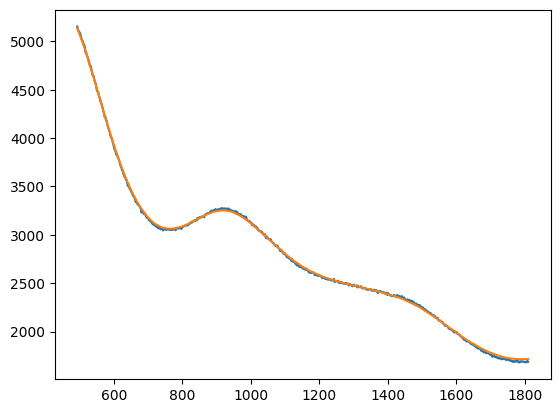

In [4]:


def _device(device):
    if device is None:
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device(device)


def _to_tensor(arr, device):
    return torch.as_tensor(arr, dtype=torch.float64, device=device)


def _extrapolate_pad(data_np, rs_np, pad, fit_points=6, poly_order=1):
    """Pad both ends of the spectral axis by extrapolating a polynomial fit.

    Parameters
    ----------
    data_np    : ndarray (..., n)
    rs_np      : 1-D array (n,)
    pad        : number of points to add at each end
    fit_points : how many edge points to fit (default 6)
    poly_order : polynomial degree (1 = linear, 2 = quadratic; default 1)

    Returns
    -------
    rs_pad   : 1-D array (n + 2*pad,)
    data_pad : ndarray (..., n + 2*pad)
    """
    n = rs_np.shape[0]
    fit_points = min(fit_points, n)
    poly_order = min(poly_order, fit_points - 1)

    # Extrapolated wavenumber grids (uniform spacing assumed at edges)
    step_left  = rs_np[1] - rs_np[0]
    step_right = rs_np[-1] - rs_np[-2]
    rs_left  = rs_np[0]  + step_left  * np.arange(-pad, 0)   # ascending
    rs_right = rs_np[-1] + step_right * np.arange(1, pad + 1)
    rs_pad   = np.concatenate([rs_left, rs_np, rs_right])

    orig_shape = data_np.shape
    flat = data_np.reshape(-1, n)           # (batch, n)

    # --- left pad ---
    x_fit_l = rs_np[:fit_points]
    coeffs_l = np.polyfit(x_fit_l, flat[:, :fit_points].T, poly_order)  # (order+1, batch)
    left_pad  = np.polyval(coeffs_l, rs_left[:, None]).T                 # (batch, pad)

    # --- right pad ---
    x_fit_r = rs_np[-fit_points:]
    coeffs_r = np.polyfit(x_fit_r, flat[:, -fit_points:].T, poly_order)
    right_pad = np.polyval(coeffs_r, rs_right[:, None]).T                # (batch, pad)

    data_pad = np.concatenate([left_pad, flat, right_pad], axis=-1)
    return rs_pad, data_pad.reshape(orig_shape[:-1] + (n + 2 * pad,))


def adaptive_running_average(
    data,
    raman_shift,
    width=0.05,
    window_ratio=1.0,
    shape_mode="uniform",
    padding="extrapolate",
    fit_points=6,
    poly_order=1,
    device=None,
):
    """Adaptive running average along the spectral axis.

    Window half-width scales with wavenumber:
        half_width[i] = width * raman_shift[i] ** window_ratio

    Parameters
    ----------
    data         : array-like, any shape; last axis is spectral
    raman_shift  : 1-D array of wavenumbers matching data.shape[-1]
    width        : base multiplier for the adaptive half-width (default 0.05)
    window_ratio : dispersion exponent (default 1.0)
    shape_mode   : weighting kernel — one of:
                     'uniform'     equal weight inside the window
                     'linear'      weight = 1 - distance / half_width
                     'exponential' weight = exp(-3 * distance / half_width)
                     'gaussian'    weight = exp(-0.5 * (distance / 0.4*half_width)^2)
    padding      : edge treatment —
                     'extrapolate' (default) fits a polynomial to each edge and
                                  extends the spectrum outward before smoothing
                     'reflect'    mirrors the spectrum at both ends
                     'none'       no padding (original behaviour, artefacts at edges)
    fit_points   : number of edge points used for the extrapolation fit (default 6)
    poly_order   : polynomial degree for extrapolation — 1 = linear (default),
                   2 = quadratic; clamped to fit_points - 1
    device       : torch device string/object (default: CUDA if available)

    Returns
    -------
    torch.Tensor — smoothed data, same shape as input, on `device`
    """
    dev = _device(device)
    data_np = np.asarray(data, dtype=float)
    rs_np   = np.asarray(raman_shift, dtype=float)

    if data_np.shape[-1] != len(rs_np):
        raise ValueError("raman_shift length must match the last axis of data.")

    original_shape = data_np.shape
    n = original_shape[-1]

    window_half_wn = width * rs_np ** window_ratio

    # --- padding ------------------------------------------------------
    if padding in ("extrapolate", "reflect"):
        pad = int(np.ceil(window_half_wn.max() / np.min(np.diff(rs_np))))
        pad = min(pad, n - 1)

        if padding == "extrapolate":
            rs_pad, data_pad = _extrapolate_pad(
                data_np, rs_np, pad, fit_points=fit_points, poly_order=poly_order
            )
        else:  # reflect
            rs_pad = np.concatenate([
                2 * rs_np[0]  - rs_np[pad:0:-1],
                rs_np,
                2 * rs_np[-1] - rs_np[-2:-pad - 2:-1],
            ])
            data_pad = np.concatenate([
                data_np[..., pad:0:-1],
                data_np,
                data_np[..., -2:-pad - 2:-1],
            ], axis=-1)

        hw_pad = width * rs_pad ** window_ratio

    elif padding == "none":
        pad, rs_pad, data_pad = 0, rs_np, data_np
        hw_pad = window_half_wn
    else:
        raise ValueError(f"Unknown padding: {padding!r}")

    n_pad = rs_pad.shape[0]

    # --- weight kernel ------------------------------------------------
    decay = 3.0
    sigma_frac = 0.4

    def get_weights(distances: torch.Tensor, half_width: float) -> torch.Tensor:
        if shape_mode == "uniform":
            return torch.ones(distances.shape[0], dtype=torch.float64, device=dev)
        elif shape_mode == "linear":
            return 1.0 - distances / half_width
        elif shape_mode == "exponential":
            return torch.exp(-decay * distances / half_width)
        elif shape_mode == "gaussian":
            sigma = sigma_frac * half_width
            return torch.exp(-0.5 * (distances / sigma) ** 2)
        else:
            raise ValueError(f"Unknown shape_mode: {shape_mode!r}")

    # --- weight matrix ------------------------------------------------
    rs_t = _to_tensor(rs_pad, device=dev)
    hw_t = _to_tensor(hw_pad, device=dev)

    W = torch.zeros(n_pad, n_pad, dtype=torch.float64, device=dev)
    for i in range(n_pad):
        center = rs_t[i]
        hw     = hw_t[i].item()
        mask   = (rs_t >= center - hw) & (rs_t <= center + hw)
        distances = torch.abs(rs_t[mask] - center)
        weights   = get_weights(distances, hw)
        weights   = weights / weights.sum()
        W[i, mask] = weights

    # --- apply and strip padding --------------------------------------
    data_t     = _to_tensor(data_pad.reshape(-1, n_pad), device=dev)
    smoothed_t = data_t @ W.t()

    if pad > 0:
        smoothed_t = smoothed_t[:, pad: pad + n]

    return smoothed_t.reshape(original_shape)




nrb_estimate = adaptive_running_average(
    I_CARS, wn, width = 0.05,)

plt.plot(wn, I_CARS[pixely, pixelx], label='Noisy CARS')
plt.plot(wn, nrb_estimate[pixely, pixelx].cpu(), label = "nrb_estimate")

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
_LOG2          = torch.log(torch.tensor(2.0))
_SQRT_4LOG2    = torch.sqrt(4.0 * _LOG2)
_2_OVER_SQRTPI = 2.0 / torch.sqrt(torch.tensor(torch.pi))
_LOG2          = _LOG2.to(device)
_SQRT_4LOG2    = _SQRT_4LOG2.to(device)
_2_OVER_SQRTPI = _2_OVER_SQRTPI.to(device)

def _dawson(t: torch.Tensor) -> torch.Tensor:
    t2    = t * t
    small = t * (1.0 - t2 * (2.0/3.0 - t2 * (4.0/15.0 - t2 * (8.0/105.0))))
    t_safe = t.abs().clamp(min=1e-6)
    t_safe = torch.copysign(t_safe, t)
    t2s    = t_safe * t_safe
    large  = 0.5 / t_safe * (1.0 + 0.5 / t2s * (1.0 + 1.5 / t2s))
    return torch.where(t.abs() < 1.8, small, large)


def pseudo_voigt_dispersive(x, sigma, gamma):
    sigma = sigma.clamp(min=1e-6)
    gamma = gamma.clamp(min=1e-6)

    fwhm_g = 2.35482 * sigma
    fwhm_l = 2.0     * gamma

    fwhm = (
        fwhm_g**5
        + 2.69269 * fwhm_g**4 * fwhm_l
        + 2.42843 * fwhm_g**3 * fwhm_l**2
        + 4.47163 * fwhm_g**2 * fwhm_l**3
        + 0.07842 * fwhm_g    * fwhm_l**4
        +                       fwhm_l**5
    ) ** 0.2
    fwhm = fwhm.clamp(min=1e-6)

    ratio = fwhm_l / fwhm
    eta   = (1.36603 * ratio - 0.47719 * ratio**2 + 0.11116 * ratio**3).clamp(0.0, 1.0)

    z = (x / fwhm).clamp(-50.0, 50.0)

    disp_lorentzian = 2.0 * z / (1.0 + 4.0 * z**2)

    t             = _SQRT_4LOG2 * z
    disp_gaussian = _dawson(t) * _2_OVER_SQRTPI

    return eta * disp_lorentzian + (1.0 - eta) * disp_gaussian

def compute_model(p, x):
    """
    Vectorized computation of all peaks using broadcasting.
    Replaces jax.vmap — no loop needed.

    Args:
        p: torch tensor of shape (n_peaks * 4,)
        x: torch tensor of x-values
    """
    p    = _to_tensor(p, device)
    x    = _to_tensor(x, device)
    p_r  = p.reshape(-1, 4)
    amps = p_r[:, 0].unsqueeze(1)  # (n_peaks, 1)
    ctrs = p_r[:, 1].unsqueeze(1)  # (n_peaks, 1)
    sigs = p_r[:, 2].unsqueeze(1)  # (n_peaks, 1)
    gams = p_r[:, 3].unsqueeze(1)  # (n_peaks, 1)

    x_shifted = x.unsqueeze(0) - ctrs          # (n_peaks, n_points)
    pv = pseudo_voigt_dispersive(x_shifted, sigs, gams)   # (n_peaks, n_points)
    return (amps * pv).sum(0)                   #


H, W, P = params.shape  # 289, 253, 800
n_peaks = P // 4        # 200
n_pixels = H * W        # 73117

params_flat = params.reshape(n_pixels, n_peaks, 4)  # (73117, 200, 4)
params_flat = _to_tensor(params_flat, device)
x           = _to_tensor(wn, device)                # (n_points,)

chunk_size  = 1024  # pixels per chunk, tune to your VRAM

results = []
n_chunks = (n_pixels + chunk_size - 1) // chunk_size
model_antisym = torch.zeros(n_pixels, len(wn), dtype=torch.float32)

for i in range(0, n_pixels, chunk_size):
    p_chunk = params_flat[i : i + chunk_size]

    amps = p_chunk[..., 0:1]
    ctrs = p_chunk[..., 1:2]
    sigs = p_chunk[..., 2:3]
    gams = p_chunk[..., 3:4]

    x_shifted = x - ctrs
    pv        = pseudo_voigt_dispersive(x_shifted, sigs, gams)
    result    = (amps * pv).sum(1)
    print(f"Chunk {i // chunk_size + 1} / {n_chunks}")
    model_antisym[i : i + chunk_size] = result.cpu()
    
    del p_chunk, amps, ctrs, sigs, gams, x_shifted, pv, result
    torch.cuda.empty_cache()


model_antisym = model_antisym.reshape(H, W, -1)


Chunk 1 / 72
0.504702464 GB
Chunk 2 / 72
0.504702464 GB
Chunk 3 / 72
0.504702464 GB
Chunk 4 / 72
0.504702464 GB
Chunk 5 / 72
0.504702464 GB
Chunk 6 / 72
0.504702464 GB
Chunk 7 / 72
0.504702464 GB
Chunk 8 / 72
0.504702464 GB
Chunk 9 / 72
0.504702464 GB
Chunk 10 / 72
0.504702464 GB
Chunk 11 / 72
0.504702464 GB
Chunk 12 / 72
0.504702464 GB
Chunk 13 / 72
0.504702464 GB
Chunk 14 / 72
0.504702464 GB
Chunk 15 / 72
0.504702464 GB
Chunk 16 / 72
0.504702464 GB
Chunk 17 / 72
0.504702464 GB
Chunk 18 / 72
0.504702464 GB
Chunk 19 / 72
0.504702464 GB
Chunk 20 / 72
0.504702464 GB
Chunk 21 / 72
0.504702464 GB
Chunk 22 / 72
0.504702464 GB
Chunk 23 / 72
0.504702464 GB
Chunk 24 / 72
0.504702464 GB
Chunk 25 / 72
0.504702464 GB
Chunk 26 / 72
0.504702464 GB
Chunk 27 / 72
0.504702464 GB
Chunk 28 / 72
0.504702464 GB
Chunk 29 / 72
0.504702464 GB
Chunk 30 / 72


In [ ]:
import h5py

with h5py.File('/home/adiering3/projects/CRIkit3/phantom_PG_noise_shot5.2.h5', 'a') as f:
    if 'GT/model_antisym' in f:
        raise ValueError("Dataset GT/model_antisym already exists")
    f.create_dataset(
        'GT/model_antisym',
        data=model_antisym.numpy(),  # or .cpu().numpy() if still on GPU
        compression='gzip',
        compression_opts=4
    )